# LightGBM & CatBoost Hyperparameter Tuning

## Objective

This notebook tunes hyperparameters for the two shortlisted models:

- LightGBM trained on `target_price`
- CatBoost trained on `target_price`

The main goal is not only to find the best tuned parameters, but also to verify whether tuning actually improves the baseline models.

The primary selection metric is RMSE because large pricing errors are costly in this problem. MAE and MAPE are used as secondary metrics to understand average error and relative error.

A tuned model should only replace its baseline if it improves RMSE and does not introduce worse behavior on MAE, MAPE, or large-error cases.

`log_target_price` is not tuned in this notebook. If it exists in the dataframe, it is only removed from the feature matrix to prevent leakage.

After this update, the role of this notebook is: **Hyperparameter tuning + Cross-validation model selection**. Notebook 14 should focus on final model evaluation, diagnostics, error analysis, and export.

## 2. Imports & Config


In [1]:
from __future__ import annotations

import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.base import clone
from sklearn.metrics import (
    max_error,
    mean_absolute_error,
    mean_squared_error,
    median_absolute_error,
    r2_score,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split

try:
    from sklearn.metrics import root_mean_squared_error
except ImportError:
    from sklearn.metrics import mean_squared_error

    def root_mean_squared_error(y_true, y_pred):
        return mean_squared_error(y_true, y_pred, squared=False)

from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")


In [2]:
RANDOM_STATE = 42
TEST_SIZE = 0.20

current_path = Path.cwd().resolve()
if (current_path / "data" / "processed" / "final_dataset.csv").exists():
    PROJECT_ROOT = current_path
elif current_path.name == "modeling" and current_path.parent.name == "notebooks":
    PROJECT_ROOT = current_path.parents[1]
else:
    PROJECT_ROOT = current_path

DATA_PATH = PROJECT_ROOT / "data" / "processed" / "final_dataset.csv"

OUTPUT_DIR = PROJECT_ROOT / "artifacts" / "hyperparameter_tuning"
MODEL_DIR = OUTPUT_DIR / "models"
METRIC_DIR = OUTPUT_DIR / "metrics"
PARAM_DIR = OUTPUT_DIR / "params"
PRED_DIR = OUTPUT_DIR / "predictions"

for d in [MODEL_DIR, METRIC_DIR, PARAM_DIR, PRED_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Data path: {DATA_PATH}")
print(f"Output directory: {OUTPUT_DIR}")

# ── Report artifact mirroring ─────────────────────────────────────────────────
# Keep the original artifact paths for downstream notebooks, and mirror every
# generated table/figure into reports/tables and reports/figures for the report.
NOTEBOOK_SLUG = "13_lightgbm_catboost_hyperparameter_tuning"
REPORT_DIR = PROJECT_ROOT / "reports"
REPORT_FIGURES_DIR = REPORT_DIR / "figures" / NOTEBOOK_SLUG
REPORT_TABLES_DIR = REPORT_DIR / "tables" / NOTEBOOK_SLUG
for directory in [REPORT_FIGURES_DIR, REPORT_TABLES_DIR]:
    directory.mkdir(parents=True, exist_ok=True)


def _report_relative_path(path):
    path = Path(path)
    try:
        path = path.resolve()
    except OSError:
        path = path.absolute()
    for base in [PROJECT_ROOT / "artifacts", PROJECT_ROOT / "reports", PROJECT_ROOT]:
        try:
            return path.relative_to(base.resolve())
        except ValueError:
            continue
    return Path(path.name)


def _mirror_report_artifact(path, destination_root):
    if path is None or destination_root is None or not isinstance(path, (str, Path)):
        return
    src = Path(path)
    if not src.exists() or not src.is_file():
        return
    rel = _report_relative_path(src)
    dst = destination_root / rel
    try:
        if src.resolve() == dst.resolve():
            return
    except OSError:
        pass
    dst.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy2(src, dst)


import shutil
from matplotlib.figure import Figure

if not hasattr(pd.DataFrame, "_reports_original_to_csv"):
    pd.DataFrame._reports_original_to_csv = pd.DataFrame.to_csv
if not hasattr(pd.Series, "_reports_original_to_csv"):
    pd.Series._reports_original_to_csv = pd.Series.to_csv
if not hasattr(pd.DataFrame, "_reports_original_to_excel"):
    pd.DataFrame._reports_original_to_excel = pd.DataFrame.to_excel
if not hasattr(Figure, "_reports_original_savefig"):
    Figure._reports_original_savefig = Figure.savefig


def _to_csv_with_report_mirror(self, path_or_buf=None, *args, **kwargs):
    result = pd.DataFrame._reports_original_to_csv(self, path_or_buf, *args, **kwargs)
    _mirror_report_artifact(path_or_buf, globals().get("REPORT_TABLES_DIR"))
    return result


def _series_to_csv_with_report_mirror(self, path_or_buf=None, *args, **kwargs):
    result = pd.Series._reports_original_to_csv(self, path_or_buf, *args, **kwargs)
    _mirror_report_artifact(path_or_buf, globals().get("REPORT_TABLES_DIR"))
    return result


def _to_excel_with_report_mirror(self, excel_writer, *args, **kwargs):
    result = pd.DataFrame._reports_original_to_excel(self, excel_writer, *args, **kwargs)
    _mirror_report_artifact(excel_writer, globals().get("REPORT_TABLES_DIR"))
    return result


def _savefig_with_report_mirror(self, fname, *args, **kwargs):
    result = Figure._reports_original_savefig(self, fname, *args, **kwargs)
    _mirror_report_artifact(fname, globals().get("REPORT_FIGURES_DIR"))
    return result


_to_csv_with_report_mirror._reports_mirror_patch = True
_series_to_csv_with_report_mirror._reports_mirror_patch = True
_to_excel_with_report_mirror._reports_mirror_patch = True
_savefig_with_report_mirror._reports_mirror_patch = True
pd.DataFrame.to_csv = _to_csv_with_report_mirror
pd.Series.to_csv = _series_to_csv_with_report_mirror
pd.DataFrame.to_excel = _to_excel_with_report_mirror
Figure.savefig = _savefig_with_report_mirror

print(f"Report figures mirrored to: {REPORT_FIGURES_DIR}")
print(f"Report tables mirrored to : {REPORT_TABLES_DIR}")


Project root: Y:\Python\Laptop-Price-Prediction
Data path: Y:\Python\Laptop-Price-Prediction\data\processed\final_dataset.csv
Output directory: Y:\Python\Laptop-Price-Prediction\artifacts\hyperparameter_tuning
Report figures mirrored to: Y:\Python\Laptop-Price-Prediction\reports\figures\13_lightgbm_catboost_hyperparameter_tuning
Report tables mirrored to : Y:\Python\Laptop-Price-Prediction\reports\tables\13_lightgbm_catboost_hyperparameter_tuning


## 3. Load Data

Load dataframe final đã được preprocessing từ notebook trước. Notebook này không tạo lại feature engineering và không dùng `log_target_price` làm target.


In [3]:
df = pd.read_csv(DATA_PATH)

required_targets = ["target_price"]
missing_targets = [c for c in required_targets if c not in df.columns]
if missing_targets:
    raise ValueError(f"Missing required target columns: {missing_targets}")

drop_cols = ["target_price", "log_target_price"]
X = df.drop(columns=[c for c in drop_cols if c in df.columns], errors="ignore")
y = df["target_price"]

X = X.select_dtypes(include=[np.number]).copy()
feature_names = X.columns.tolist()

print(f"DataFrame shape: {df.shape}")
print(f"Feature matrix shape: {X.shape}")
print(f"Number of features: {len(feature_names)}")
print("Target distribution summary:")
display(y.describe().to_frame("target_price"))

if X.empty:
    raise ValueError("Feature matrix is empty after selecting numeric features.")


DataFrame shape: (7296, 88)
Feature matrix shape: (7296, 86)
Number of features: 86
Target distribution summary:


,target_price
count,"7,296.0000"
mean,14.9491
std,15.3312
min,1.0000
25%,5.6000
50%,10.5000
75%,18.8125
max,179.4000


## 4. Fixed Stratified Train/Test Split

Dùng một split 80/20 cố định cho toàn bộ baseline và tuned models. Test set chỉ được dùng sau khi model hoặc best estimator đã được xác định.

The holdout split is stratified by price segment to keep the train/test price distribution similar. This is important because laptop prices are skewed and high-price samples can strongly affect RMSE.

In [4]:
price_segment_holdout = pd.qcut(
    y,
    q=5,
    labels=False,
    duplicates="drop",
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=price_segment_holdout,
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")
print("Holdout price segment distribution:")
display(
    pd.DataFrame({
        "full": pd.Series(price_segment_holdout).value_counts(normalize=True).sort_index(),
        "train": pd.Series(price_segment_holdout.loc[X_train.index]).value_counts(normalize=True).sort_index(),
        "test": pd.Series(price_segment_holdout.loc[X_test.index]).value_counts(normalize=True).sort_index(),
    })
)

X_train shape: (5836, 86)
X_test shape: (1460, 86)
y_train shape: (5836,)
y_test shape: (1460,)
Holdout price segment distribution:


,full,train,test
target_price,,,
0,0.2007,0.2007,0.2007
1,0.2024,0.2024,0.2027
2,0.1976,0.1977,0.1973
3,0.1993,0.1993,0.1993
4,0.2000,0.2000,0.2000


## 5. Metric Helper Functions


In [5]:
def safe_mape_pct(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def safe_ape_pct(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    ape = np.full(shape=len(y_true), fill_value=np.nan, dtype=float)
    mask = y_true != 0
    ape[mask] = np.abs((y_true[mask] - y_pred[mask]) / y_true[mask]) * 100

    return ape


def evaluate_regression(y_true, y_pred):
    residual = np.asarray(y_true) - np.asarray(y_pred)

    return {
        "mae": mean_absolute_error(y_true, y_pred),
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "r2": r2_score(y_true, y_pred),
        "mape_pct": safe_mape_pct(y_true, y_pred),
        "median_ae": median_absolute_error(y_true, y_pred),
        "max_error": max_error(y_true, y_pred),
    }


def build_prediction_frame(y_true, y_pred, model_name, version, sample_index=None):
    actual = np.asarray(y_true)
    predicted = np.asarray(y_pred)
    residual = actual - predicted
    abs_error = np.abs(residual)
    ape_pct = safe_ape_pct(actual, predicted)

    if sample_index is None:
        sample_index = np.arange(len(actual))

    return pd.DataFrame({
        "sample_index": sample_index,
        "actual_price": actual,
        "predicted_price": predicted,
        "residual": residual,
        "abs_error": abs_error,
        "ape_pct": ape_pct,
        "model_name": model_name,
        "version": version,
    })


def fit_evaluate_model(model, X_train, y_train, X_test, y_test, model_name, version):
    print(f"Training {model_name} ({version})...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    metrics = evaluate_regression(y_test, y_pred)
    metrics.update({"model_name": model_name, "version": version})

    prediction_df = build_prediction_frame(
        y_test,
        y_pred,
        model_name=model_name,
        version=version,
        sample_index=X_test.index,
    )

    print(f"{model_name} ({version}) test metrics:")
    display(pd.DataFrame([metrics]))

    return metrics, prediction_df


def make_json_serializable(obj):
    if isinstance(obj, dict):
        return {k: make_json_serializable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [make_json_serializable(v) for v in obj]
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        return float(obj)
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj

## 6. Baseline Models

Train lại 2 baseline model với params hợp lý gần với notebook trước, dùng `target_price` trực tiếp.


In [6]:
baseline_results = []
prediction_frames = []

lgbm_baseline = LGBMRegressor(
    objective="regression",
    random_state=RANDOM_STATE,
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
)

cat_baseline = CatBoostRegressor(
    loss_function="RMSE",
    random_seed=RANDOM_STATE,
    iterations=500,
    learning_rate=0.05,
    depth=6,
    verbose=False,
    allow_writing_files=False,
    thread_count=1,
)

for model_name, model in [
    ("LightGBM", lgbm_baseline),
    ("CatBoost", cat_baseline),
]:
    metrics, preds = fit_evaluate_model(
        model,
        X_train,
        y_train,
        X_test,
        y_test,
        model_name=model_name,
        version="baseline",
    )
    baseline_results.append(metrics)
    prediction_frames.append(preds)

baseline_results_df = pd.DataFrame(baseline_results)
display(baseline_results_df)


Training LightGBM (baseline)...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002784 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 404
[LightGBM] [Info] Number of data points in the train set: 5836, number of used features: 85
[LightGBM] [Info] Start training from score 14.956336
LightGBM (baseline) test metrics:


,mae,rmse,r2,mape_pct,median_ae,max_error,model_name,version
0,3.3666,5.7849,0.8559,31.9004,1.9176,51.6980,LightGBM,baseline


Training CatBoost (baseline)...
CatBoost (baseline) test metrics:


,mae,rmse,r2,mape_pct,median_ae,max_error,model_name,version
0,3.4741,5.8193,0.8542,33.5088,2.0580,51.9096,CatBoost,baseline


,mae,rmse,r2,mape_pct,median_ae,max_error,model_name,version
0,3.3666,5.7849,0.8559,31.9004,1.9176,51.6980,LightGBM,baseline
1,3.4741,5.8193,0.8542,33.5088,2.0580,51.9096,CatBoost,baseline


In [7]:
# ============================================================
# Save baseline models
# ============================================================

joblib.dump(
    lgbm_baseline,
    MODEL_DIR / "lightgbm_target_price_baseline.pkl",
)

joblib.dump(
    cat_baseline,
    MODEL_DIR / "catboost_target_price_baseline.pkl",
)

print("Saved baseline models:")
print(MODEL_DIR / "lightgbm_target_price_baseline.pkl")
print(MODEL_DIR / "catboost_target_price_baseline.pkl")


Saved baseline models:
Y:\Python\Laptop-Price-Prediction\artifacts\hyperparameter_tuning\models\lightgbm_target_price_baseline.pkl
Y:\Python\Laptop-Price-Prediction\artifacts\hyperparameter_tuning\models\catboost_target_price_baseline.pkl


## CV Search Result Summary

This section checks whether the best tuned configuration is clearly better than nearby configurations.

If many configurations have very similar CV RMSE, the tuning result should be interpreted cautiously because the model may be insensitive to the searched hyperparameter range.

## Stratified CV for Hyperparameter Search

The hyperparameter search uses stratified cross-validation based on quantile price segments. Although the task is regression, stratifying by target price bins helps keep low-price and high-price laptops balanced across folds.

This makes tuning less dependent on one particular split of the price distribution.

In [8]:
# ============================================================
# Stratified CV split for hyperparameter tuning
# ============================================================

price_segment_train = pd.qcut(
    y_train,
    q=5,
    labels=False,
    duplicates="drop",
)

tuning_cv = list(
    StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=RANDOM_STATE,
    ).split(X_train, price_segment_train)
)

print(f"Number of tuning CV folds: {len(tuning_cv)}")
print("Train price segment distribution:")
print(pd.Series(price_segment_train).value_counts(normalize=True).sort_index())


Number of tuning CV folds: 5
Train price segment distribution:
target_price
0   0.2007
1   0.2024
2   0.1977
3   0.1993
4   0.2000
Name: proportion, dtype: float64


## 7. LightGBM Hyperparameter Tuning

Dùng `RandomizedSearchCV` trên train set, scoring theo `neg_root_mean_squared_error`. Test set không được dùng trong quá trình CV.


In [9]:
lgbm_param_dist = {
    "n_estimators": [500, 800, 1200, 1600],
    "learning_rate": [0.01, 0.03, 0.05, 0.08],
    "num_leaves": [15, 31, 63, 127],
    "max_depth": [-1, 4, 6, 8, 10],
    "min_child_samples": [10, 20, 40, 80],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0, 0.01, 0.1, 1],
    "reg_lambda": [0, 0.01, 0.1, 1, 5],
}

lgbm_model = LGBMRegressor(
    objective="regression",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

lgbm_search = RandomizedSearchCV(
    estimator=lgbm_model,
    param_distributions=lgbm_param_dist,
    n_iter=40,
    scoring="neg_root_mean_squared_error",
    cv=tuning_cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

lgbm_search.fit(X_train, y_train)

print("LightGBM best params:")
print(lgbm_search.best_params_)
print(f"LightGBM best CV RMSE: {-lgbm_search.best_score_:,.4f}")

lgbm_cv_results_df = pd.DataFrame(lgbm_search.cv_results_)
lgbm_cv_results_df["mean_rmse"] = -lgbm_cv_results_df["mean_test_score"]
lgbm_cv_results_df.to_csv(METRIC_DIR / "lightgbm_cv_results.csv", index=False)

lgbm_top10 = (
    lgbm_cv_results_df
    .sort_values("mean_rmse")
    .head(10)
)

print("Top 10 LightGBM CV configurations:")
display(lgbm_top10[[
    "mean_rmse",
    "std_test_score",
    "rank_test_score",
    "params",
]])

lgbm_top10.to_csv(METRIC_DIR / "lightgbm_top10_cv_configs.csv", index=False)

with open(PARAM_DIR / "best_params_lightgbm.json", "w", encoding="utf-8") as f:
    json.dump(make_json_serializable(lgbm_search.best_params_), f, indent=2)

lgbm_tuned = lgbm_search.best_estimator_
lgbm_tuned_metrics, lgbm_tuned_preds = fit_evaluate_model(
    lgbm_tuned,
    X_train,
    y_train,
    X_test,
    y_test,
    model_name="LightGBM",
    version="tuned",
)

joblib.dump(lgbm_tuned, MODEL_DIR / "lightgbm_target_price_tuned.pkl")
prediction_frames.append(lgbm_tuned_preds)

print(f"Saved LightGBM CV results: {METRIC_DIR / 'lightgbm_cv_results.csv'}")
print(f"Saved LightGBM top 10 CV configs: {METRIC_DIR / 'lightgbm_top10_cv_configs.csv'}")
print(f"Saved LightGBM best params: {PARAM_DIR / 'best_params_lightgbm.json'}")
print(f"Saved LightGBM tuned model: {MODEL_DIR / 'lightgbm_target_price_tuned.pkl'}")


Fitting 5 folds for each of 40 candidates, totalling 200 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001952 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 406
[LightGBM] [Info] Number of data points in the train set: 5836, number of used features: 86
[LightGBM] [Info] Start training from score 14.956336
LightGBM best params:
{'subsample': 1.0, 'reg_lambda': 0, 'reg_alpha': 1, 'num_leaves': 15, 'n_estimators': 1600, 'min_child_samples': 10, 'max_depth': 10, 'learning_rate': 0.03, 'colsample_bytree': 0.8}
LightGBM best CV RMSE: 5.3649
Top 10 LightGBM CV configurations:


,mean_rmse,std_test_score,rank_test_score,params
36,5.3649,0.2019,1,"{'subsample': 1.0, 'reg_lambda': 0, 'reg_alpha..."
16,5.3720,0.2428,2,"{'subsample': 0.9, 'reg_lambda': 0.1, 'reg_alp..."
10,5.3917,0.2072,3,"{'subsample': 0.9, 'reg_lambda': 5, 'reg_alpha..."
29,5.3949,0.2240,4,"{'subsample': 1.0, 'reg_lambda': 5, 'reg_alpha..."
39,5.4154,0.2033,5,"{'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha..."
23,5.4509,0.2340,6,"{'subsample': 0.8, 'reg_lambda': 0.1, 'reg_alp..."
3,5.4514,0.2003,7,"{'subsample': 0.9, 'reg_lambda': 5, 'reg_alpha..."
14,5.4563,0.2323,8,"{'subsample': 1.0, 'reg_lambda': 1, 'reg_alpha..."
19,5.4668,0.2234,9,"{'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha..."
35,5.4690,0.1994,10,"{'subsample': 0.8, 'reg_lambda': 0, 'reg_alpha..."


Training LightGBM (tuned)...
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001773 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 406
[LightGBM] [Info] Number of data points in the train set: 5836, number of used features: 86
[LightGBM] [Info] Start training from score 14.956336
LightGBM (tuned) test metrics:


,mae,rmse,r2,mape_pct,median_ae,max_error,model_name,version
0,3.3703,5.8423,0.8531,31.6658,1.8741,51.8173,LightGBM,tuned


Saved LightGBM CV results: Y:\Python\Laptop-Price-Prediction\artifacts\hyperparameter_tuning\metrics\lightgbm_cv_results.csv
Saved LightGBM top 10 CV configs: Y:\Python\Laptop-Price-Prediction\artifacts\hyperparameter_tuning\metrics\lightgbm_top10_cv_configs.csv
Saved LightGBM best params: Y:\Python\Laptop-Price-Prediction\artifacts\hyperparameter_tuning\params\best_params_lightgbm.json
Saved LightGBM tuned model: Y:\Python\Laptop-Price-Prediction\artifacts\hyperparameter_tuning\models\lightgbm_target_price_tuned.pkl


## 8. CatBoost Hyperparameter Tuning

Dùng `RandomizedSearchCV` trên train set, scoring theo `neg_root_mean_squared_error`. Test set chỉ dùng để evaluate best estimator sau tuning.


In [10]:
cat_param_dist = {
    "iterations": [500, 800, 1200, 1600],
    "learning_rate": [0.01, 0.03, 0.05, 0.08],
    "depth": [4, 5, 6, 7, 8, 10],
    "l2_leaf_reg": [1, 3, 5, 7, 10, 15],
    "bagging_temperature": [0, 0.5, 1, 2, 5],
    "random_strength": [0, 0.5, 1, 2, 5],
}

cat_model = CatBoostRegressor(
    loss_function="RMSE",
    random_seed=RANDOM_STATE,
    verbose=False,
    allow_writing_files=False,
    thread_count=1,
)

cat_search = RandomizedSearchCV(
    estimator=cat_model,
    param_distributions=cat_param_dist,
    n_iter=40,
    scoring="neg_root_mean_squared_error",
    cv=tuning_cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)

cat_search.fit(X_train, y_train)

print("CatBoost best params:")
print(cat_search.best_params_)
print(f"CatBoost best CV RMSE: {-cat_search.best_score_:,.4f}")

cat_cv_results_df = pd.DataFrame(cat_search.cv_results_)
cat_cv_results_df["mean_rmse"] = -cat_cv_results_df["mean_test_score"]
cat_cv_results_df.to_csv(METRIC_DIR / "catboost_cv_results.csv", index=False)

cat_top10 = (
    cat_cv_results_df
    .sort_values("mean_rmse")
    .head(10)
)

print("Top 10 CatBoost CV configurations:")
display(cat_top10[[
    "mean_rmse",
    "std_test_score",
    "rank_test_score",
    "params",
]])

cat_top10.to_csv(METRIC_DIR / "catboost_top10_cv_configs.csv", index=False)

with open(PARAM_DIR / "best_params_catboost.json", "w", encoding="utf-8") as f:
    json.dump(make_json_serializable(cat_search.best_params_), f, indent=2)

cat_tuned = cat_search.best_estimator_
cat_tuned_metrics, cat_tuned_preds = fit_evaluate_model(
    cat_tuned,
    X_train,
    y_train,
    X_test,
    y_test,
    model_name="CatBoost",
    version="tuned",
)

joblib.dump(cat_tuned, MODEL_DIR / "catboost_target_price_tuned.pkl")
prediction_frames.append(cat_tuned_preds)

print(f"Saved CatBoost CV results: {METRIC_DIR / 'catboost_cv_results.csv'}")
print(f"Saved CatBoost top 10 CV configs: {METRIC_DIR / 'catboost_top10_cv_configs.csv'}")
print(f"Saved CatBoost best params: {PARAM_DIR / 'best_params_catboost.json'}")
print(f"Saved CatBoost tuned model: {MODEL_DIR / 'catboost_target_price_tuned.pkl'}")


Fitting 5 folds for each of 40 candidates, totalling 200 fits


y:\Python\Laptop-Price-Prediction\.venv\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


CatBoost best params:
{'random_strength': 2, 'learning_rate': 0.08, 'l2_leaf_reg': 10, 'iterations': 1600, 'depth': 7, 'bagging_temperature': 5}
CatBoost best CV RMSE: 5.2256
Top 10 CatBoost CV configurations:


,mean_rmse,std_test_score,rank_test_score,params
3,5.2256,0.2352,1,"{'random_strength': 2, 'learning_rate': 0.08, ..."
30,5.2897,0.2322,2,"{'random_strength': 0.5, 'learning_rate': 0.08..."
37,5.3059,0.2820,3,"{'random_strength': 1, 'learning_rate': 0.03, ..."
17,5.3124,0.2894,4,"{'random_strength': 0, 'learning_rate': 0.03, ..."
27,5.3292,0.2899,5,"{'random_strength': 0, 'learning_rate': 0.08, ..."
31,5.3464,0.2689,6,"{'random_strength': 0, 'learning_rate': 0.08, ..."
7,5.3622,0.2944,7,"{'random_strength': 5, 'learning_rate': 0.05, ..."
4,5.3683,0.2791,8,"{'random_strength': 0.5, 'learning_rate': 0.05..."
24,5.3745,0.2861,9,"{'random_strength': 0.5, 'learning_rate': 0.05..."
20,5.3785,0.3071,10,"{'random_strength': 2, 'learning_rate': 0.01, ..."


Training CatBoost (tuned)...
CatBoost (tuned) test metrics:


,mae,rmse,r2,mape_pct,median_ae,max_error,model_name,version
0,3.3726,5.9127,0.8495,32.2540,1.9429,56.1713,CatBoost,tuned


Saved CatBoost CV results: Y:\Python\Laptop-Price-Prediction\artifacts\hyperparameter_tuning\metrics\catboost_cv_results.csv
Saved CatBoost top 10 CV configs: Y:\Python\Laptop-Price-Prediction\artifacts\hyperparameter_tuning\metrics\catboost_top10_cv_configs.csv
Saved CatBoost best params: Y:\Python\Laptop-Price-Prediction\artifacts\hyperparameter_tuning\params\best_params_catboost.json
Saved CatBoost tuned model: Y:\Python\Laptop-Price-Prediction\artifacts\hyperparameter_tuning\models\catboost_target_price_tuned.pkl


## Cross-validation Strategy

This notebook uses cross-validation in two different ways.

First, `RandomizedSearchCV` uses CV internally to select the best hyperparameters for LightGBM and CatBoost. This is the tuning CV.

Second, after tuning is complete, this notebook evaluates all candidate models again using Stratified KFold. This is the stability CV.

The stability CV is necessary because the holdout score is based on only one train/test split. A model should not be selected as final only because it performs well on one holdout split. The final decision should prioritize mean RMSE across folds and also consider RMSE standard deviation.

## Stratified KFold Stability Evaluation on Training Set

The stability evaluation is performed only on the training set.

The holdout test set must remain untouched during tuning and model selection. If the full dataset is used for KFold model selection, the holdout samples indirectly influence the final model decision, and the holdout result can no longer be treated as an independent sanity check.

Therefore, this section uses `X_train` and `y_train` only. The holdout set is used later only to compare the selected candidates as a final check.

In [11]:
def cross_validate_candidate_model(
    model,
    X,
    y,
    price_segment,
    model_name,
    version,
    n_splits=5,
):
    skf = StratifiedKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    fold_metric_rows = []
    oof_prediction_frames = []

    for fold, (train_idx, valid_idx) in enumerate(
        skf.split(X, price_segment),
        start=1,
    ):
        X_tr = X.iloc[train_idx].copy()
        X_va = X.iloc[valid_idx].copy()
        y_tr = y.iloc[train_idx].copy()
        y_va = y.iloc[valid_idx].copy()

        fold_model = clone(model)
        fold_model.fit(X_tr, y_tr)

        y_pred = fold_model.predict(X_va)

        metrics = evaluate_regression(y_va, y_pred)

        fold_metric_rows.append({
            "model_name": model_name,
            "version": version,
            "fold": fold,
            "n_train": len(train_idx),
            "n_valid": len(valid_idx),
            **metrics,
        })

        residual = y_va.values - y_pred

        fold_pred_df = pd.DataFrame({
            "sample_index": X_va.index,
            "fold": fold,
            "actual_price": y_va.values,
            "predicted_price": y_pred,
            "residual": residual,
            "abs_error": np.abs(residual),
            "ape_pct": safe_ape_pct(y_va.values, y_pred),
            "model_name": model_name,
            "version": version,
        })

        oof_prediction_frames.append(fold_pred_df)

    fold_metrics_df = pd.DataFrame(fold_metric_rows)
    oof_predictions_df = pd.concat(
        oof_prediction_frames,
        axis=0,
    ).reset_index(drop=True)

    return fold_metrics_df, oof_predictions_df

In [12]:
price_segment_cv = pd.qcut(
    y_train,
    q=5,
    labels=False,
    duplicates="drop",
)

cv_candidates = [
    ("LightGBM", "baseline", lgbm_baseline),
    ("LightGBM", "tuned", lgbm_tuned),
    ("CatBoost", "baseline", cat_baseline),
    ("CatBoost", "tuned", cat_tuned),
]

cv_metric_frames = []
cv_prediction_frames = []

for model_name, version, model in cv_candidates:
    print(f"Running Stratified KFold CV: {model_name} - {version}")

    fold_metrics_df, oof_predictions_df = cross_validate_candidate_model(
        model=model,
        X=X_train,
        y=y_train,
        price_segment=price_segment_cv,
        model_name=model_name,
        version=version,
        n_splits=5,
    )

    cv_metric_frames.append(fold_metrics_df)
    cv_prediction_frames.append(oof_predictions_df)

cv_fold_metrics_df = pd.concat(
    cv_metric_frames,
    axis=0,
).reset_index(drop=True)

cv_oof_predictions_df = pd.concat(
    cv_prediction_frames,
    axis=0,
).reset_index(drop=True)

display(cv_fold_metrics_df)

cv_fold_metrics_df.to_csv(
    METRIC_DIR / "kfold_fold_metrics.csv",
    index=False,
)
cv_fold_metrics_df.to_csv(
    METRIC_DIR / "train_kfold_fold_metrics.csv",
    index=False,
)

cv_oof_predictions_df.to_csv(
    PRED_DIR / "kfold_oof_predictions.csv",
    index=False,
)
cv_oof_predictions_df.to_csv(
    PRED_DIR / "train_kfold_oof_predictions.csv",
    index=False,
)

print(f"Saved KFold fold metrics: {METRIC_DIR / 'kfold_fold_metrics.csv'}")
print(f"Saved KFold fold metrics (train): {METRIC_DIR / 'train_kfold_fold_metrics.csv'}")
print(f"Saved KFold OOF predictions: {PRED_DIR / 'kfold_oof_predictions.csv'}")
print(f"Saved KFold OOF predictions (train): {PRED_DIR / 'train_kfold_oof_predictions.csv'}")

Running Stratified KFold CV: LightGBM - baseline
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001328 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 381
[LightGBM] [Info] Number of data points in the train set: 4668, number of used features: 80
[LightGBM] [Info] Start training from score 14.985169
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000843 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 380
[LightGBM] [Info] Number of data points in the train set: 4669, number of used features: 79
[LightGBM] [Info] Start training fr

,model_name,version,fold,n_train,n_valid,mae,rmse,r2,mape_pct,median_ae,max_error
0,LightGBM,baseline,1,4668,1168,3.3042,5.5278,0.8651,31.5961,2.0040,68.5031
1,LightGBM,baseline,2,4669,1167,3.1332,5.2336,0.8978,29.5902,1.7891,45.4150
2,LightGBM,baseline,3,4669,1167,3.1996,5.1013,0.8882,30.3113,1.8339,39.5063
3,LightGBM,baseline,4,4669,1167,3.4307,5.7218,0.8436,32.7269,1.9448,36.8912
4,LightGBM,baseline,5,4669,1167,3.4068,5.8074,0.8604,30.7320,1.8448,47.6897
5,LightGBM,tuned,1,4668,1168,3.3058,5.5302,0.8650,30.5383,1.9814,62.7097
6,LightGBM,tuned,2,4669,1167,3.1201,5.1284,0.9019,29.1450,1.8246,37.3234
7,LightGBM,tuned,3,4669,1167,3.2451,5.1343,0.8868,30.8211,1.9432,39.2412
8,LightGBM,tuned,4,4669,1167,3.3037,5.4114,0.8601,32.4274,1.9368,36.0434
9,LightGBM,tuned,5,4669,1167,3.3122,5.6203,0.8693,30.8271,1.8362,47.4977


Saved KFold fold metrics: Y:\Python\Laptop-Price-Prediction\artifacts\hyperparameter_tuning\metrics\kfold_fold_metrics.csv
Saved KFold fold metrics (train): Y:\Python\Laptop-Price-Prediction\artifacts\hyperparameter_tuning\metrics\train_kfold_fold_metrics.csv
Saved KFold OOF predictions: Y:\Python\Laptop-Price-Prediction\artifacts\hyperparameter_tuning\predictions\kfold_oof_predictions.csv
Saved KFold OOF predictions (train): Y:\Python\Laptop-Price-Prediction\artifacts\hyperparameter_tuning\predictions\train_kfold_oof_predictions.csv


In [13]:
cv_summary_df = (
    cv_fold_metrics_df
    .groupby(["model_name", "version"])
    .agg(
        mean_mae=("mae", "mean"),
        std_mae=("mae", "std"),
        mean_rmse=("rmse", "mean"),
        std_rmse=("rmse", "std"),
        mean_r2=("r2", "mean"),
        std_r2=("r2", "std"),
        mean_mape_pct=("mape_pct", "mean"),
        std_mape_pct=("mape_pct", "std"),
        mean_median_ae=("median_ae", "mean"),
        std_median_ae=("median_ae", "std"),
        mean_max_error=("max_error", "mean"),
        std_max_error=("max_error", "std"),
    )
    .reset_index()
)

cv_summary_df = cv_summary_df.sort_values(
    ["mean_rmse", "std_rmse", "mean_mae"]
).reset_index(drop=True)

display(cv_summary_df)

cv_summary_df.to_csv(
    METRIC_DIR / "kfold_cv_summary.csv",
    index=False,
)
cv_summary_df.to_csv(
    METRIC_DIR / "train_kfold_cv_summary.csv",
    index=False,
)

print(f"Saved KFold CV summary: {METRIC_DIR / 'kfold_cv_summary.csv'}")
print(f"Saved KFold CV summary (train): {METRIC_DIR / 'train_kfold_cv_summary.csv'}")

,model_name,version,mean_mae,std_mae,mean_rmse,std_rmse,mean_r2,std_r2,mean_mape_pct,std_mape_pct,mean_median_ae,std_median_ae,mean_max_error,std_max_error
0,CatBoost,tuned,3.1840,0.1137,5.2256,0.2630,0.8826,0.0200,30.6727,0.9688,1.8443,0.0685,44.8976,12.2631
1,LightGBM,tuned,3.2574,0.0814,5.3649,0.2257,0.8766,0.0174,30.7518,1.1668,1.9044,0.0698,44.5631,11.0819
2,CatBoost,baseline,3.3318,0.1496,5.4086,0.2736,0.8742,0.0218,32.3531,1.4273,1.9616,0.1431,45.8911,13.7050
3,LightGBM,baseline,3.2949,0.1287,5.4784,0.3050,0.8710,0.0219,30.9913,1.2115,1.8833,0.0882,47.6011,12.4690


Saved KFold CV summary: Y:\Python\Laptop-Price-Prediction\artifacts\hyperparameter_tuning\metrics\kfold_cv_summary.csv
Saved KFold CV summary (train): Y:\Python\Laptop-Price-Prediction\artifacts\hyperparameter_tuning\metrics\train_kfold_cv_summary.csv


In [14]:
best_cv_model = cv_summary_df.iloc[0]

cv_decision_rows = []

rmse_std_median = cv_summary_df["std_rmse"].median()

for _, row in cv_summary_df.iterrows():
    is_best = (
        row["model_name"] == best_cv_model["model_name"]
        and row["version"] == best_cv_model["version"]
    )

    if is_best and row["std_rmse"] <= rmse_std_median * 1.5:
        status = "primary_candidate"
        reason = "Best mean RMSE across Stratified KFold and stable fold-to-fold performance."
    elif is_best:
        status = "primary_candidate_with_caution"
        reason = "Best mean RMSE across Stratified KFold, but RMSE variance is relatively high."
    elif row["std_rmse"] > rmse_std_median * 1.5:
        status = "unstable_candidate"
        reason = "RMSE standard deviation across folds is relatively high."
    else:
        status = "secondary_candidate"
        reason = "Not the best by KFold mean RMSE, but remains useful as a comparison candidate."

    cv_decision_rows.append({
        "model_name": row["model_name"],
        "version": row["version"],
        "mean_rmse": row["mean_rmse"],
        "std_rmse": row["std_rmse"],
        "mean_mae": row["mean_mae"],
        "std_mae": row["std_mae"],
        "mean_mape_pct": row["mean_mape_pct"],
        "std_mape_pct": row["std_mape_pct"],
        "candidate_status": status,
        "reason": reason,
    })

cv_candidate_decision_df = pd.DataFrame(cv_decision_rows)

display(cv_candidate_decision_df)

cv_candidate_decision_df.to_csv(
    METRIC_DIR / "kfold_candidate_decision.csv",
    index=False,
)
cv_candidate_decision_df.to_csv(
    METRIC_DIR / "train_kfold_candidate_decision.csv",
    index=False,
)

print(f"Saved KFold candidate decision: {METRIC_DIR / 'kfold_candidate_decision.csv'}")

,model_name,version,mean_rmse,std_rmse,mean_mae,std_mae,mean_mape_pct,std_mape_pct,candidate_status,reason
0,CatBoost,tuned,5.2256,0.2630,3.1840,0.1137,30.6727,0.9688,primary_candidate,Best mean RMSE across Stratified KFold and sta...
1,LightGBM,tuned,5.3649,0.2257,3.2574,0.0814,30.7518,1.1668,secondary_candidate,"Not the best by KFold mean RMSE, but remains u..."
2,CatBoost,baseline,5.4086,0.2736,3.3318,0.1496,32.3531,1.4273,secondary_candidate,"Not the best by KFold mean RMSE, but remains u..."
3,LightGBM,baseline,5.4784,0.3050,3.2949,0.1287,30.9913,1.2115,secondary_candidate,"Not the best by KFold mean RMSE, but remains u..."


Saved KFold candidate decision: Y:\Python\Laptop-Price-Prediction\artifacts\hyperparameter_tuning\metrics\kfold_candidate_decision.csv


## 9. Compare Baseline vs Tuned


In [15]:
all_results = baseline_results + [lgbm_tuned_metrics, cat_tuned_metrics]
comparison_df = pd.DataFrame(all_results)

required_metric_cols = [
    "model_name",
    "version",
    "mae",
    "rmse",
    "r2",
    "mape_pct",
    "median_ae",
    "max_error",
]
comparison_df = comparison_df[required_metric_cols]

baseline_lookup = (
    comparison_df[comparison_df["version"] == "baseline"]
    .set_index("model_name")[["mae", "rmse"]]
    .rename(columns={"mae": "baseline_mae", "rmse": "baseline_rmse"})
)

comparison_df = comparison_df.merge(baseline_lookup, left_on="model_name", right_index=True, how="left")
comparison_df["delta_mae_vs_baseline"] = comparison_df["mae"] - comparison_df["baseline_mae"]
comparison_df["delta_rmse_vs_baseline"] = comparison_df["rmse"] - comparison_df["baseline_rmse"]
comparison_df["pct_mae_improvement"] = (
    (comparison_df["baseline_mae"] - comparison_df["mae"]) / comparison_df["baseline_mae"] * 100
)
comparison_df["pct_rmse_improvement"] = (
    (comparison_df["baseline_rmse"] - comparison_df["rmse"]) / comparison_df["baseline_rmse"] * 100
)
comparison_df = comparison_df.drop(columns=["baseline_mae", "baseline_rmse"])

comparison_df = comparison_df.sort_values(["rmse", "mae", "mape_pct"]).reset_index(drop=True)
comparison_df.to_csv(METRIC_DIR / "final_tuned_comparison.csv", index=False)

display(comparison_df)
print(f"Saved final comparison: {METRIC_DIR / 'final_tuned_comparison.csv'}")


,model_name,version,mae,rmse,r2,mape_pct,median_ae,max_error,delta_mae_vs_baseline,delta_rmse_vs_baseline,pct_mae_improvement,pct_rmse_improvement
0,LightGBM,baseline,3.3666,5.7849,0.8559,31.9004,1.9176,51.6980,0.0000,0.0000,0.0000,0.0000
1,CatBoost,baseline,3.4741,5.8193,0.8542,33.5088,2.0580,51.9096,0.0000,0.0000,0.0000,0.0000
2,LightGBM,tuned,3.3703,5.8423,0.8531,31.6658,1.8741,51.8173,0.0037,0.0574,-0.1093,-0.9919
3,CatBoost,tuned,3.3726,5.9127,0.8495,32.2540,1.9429,56.1713,-0.1015,0.0935,2.9210,-1.6064


Saved final comparison: Y:\Python\Laptop-Price-Prediction\artifacts\hyperparameter_tuning\metrics\final_tuned_comparison.csv


## Tuning Decision Table

This table compares each tuned model against its own baseline and turns metric deltas into an explicit decision. The decision is based on whether tuning improves the primary metric RMSE and whether secondary metrics support that replacement.

In [16]:
def build_tuning_decision_table(comparison_df):
    rows = []

    required_versions = {"baseline", "tuned"}

    for model_name in comparison_df["model_name"].unique():
        model_df = comparison_df[comparison_df["model_name"] == model_name].copy()

        if not required_versions.issubset(set(model_df["version"])):
            continue

        model_df = model_df.set_index("version")

        baseline = model_df.loc["baseline"]
        tuned = model_df.loc["tuned"]

        delta_mae = tuned["mae"] - baseline["mae"]
        delta_rmse = tuned["rmse"] - baseline["rmse"]
        delta_mape = tuned["mape_pct"] - baseline["mape_pct"]
        delta_r2 = tuned["r2"] - baseline["r2"]

        pct_mae_improvement = -delta_mae / baseline["mae"] * 100
        pct_rmse_improvement = -delta_rmse / baseline["rmse"] * 100
        pct_mape_improvement = -delta_mape / baseline["mape_pct"] * 100

        improves_rmse = delta_rmse < 0
        improves_mae = delta_mae < 0
        improves_mape = delta_mape < 0
        improves_r2 = delta_r2 > 0

        if improves_rmse and improves_mae:
            decision = "keep_tuned"
            reason = "Tuned model improves both RMSE and MAE, so it is a strong replacement candidate."
        elif (not improves_rmse) and improves_mae:
            decision = "keep_for_analysis"
            reason = "Tuned model improves MAE but worsens RMSE, suggesting a trade-off with larger errors."
        elif improves_rmse and (not improves_mae):
            decision = "keep_for_analysis"
            reason = "Tuned model improves RMSE but worsens MAE, so segment-level diagnostics are needed."
        else:
            decision = "reject_tuned"
            reason = "Tuned model does not improve the key metrics enough to replace the baseline."

        rows.append({
            "model_name": model_name,
            "baseline_mae": baseline["mae"],
            "tuned_mae": tuned["mae"],
            "delta_mae": delta_mae,
            "pct_mae_improvement": pct_mae_improvement,
            "baseline_rmse": baseline["rmse"],
            "tuned_rmse": tuned["rmse"],
            "delta_rmse": delta_rmse,
            "pct_rmse_improvement": pct_rmse_improvement,
            "baseline_mape_pct": baseline["mape_pct"],
            "tuned_mape_pct": tuned["mape_pct"],
            "delta_mape_pct": delta_mape,
            "pct_mape_improvement": pct_mape_improvement,
            "baseline_r2": baseline["r2"],
            "tuned_r2": tuned["r2"],
            "delta_r2": delta_r2,
            "improves_rmse": improves_rmse,
            "improves_mae": improves_mae,
            "improves_mape": improves_mape,
            "improves_r2": improves_r2,
            "decision": decision,
            "reason": reason,
        })

    return pd.DataFrame(rows)


decision_df = build_tuning_decision_table(comparison_df)
display(decision_df)
decision_df.to_csv(METRIC_DIR / "tuning_decision_table.csv", index=False)
print(f"Saved tuning decision table: {METRIC_DIR / 'tuning_decision_table.csv'}")

,model_name,baseline_mae,tuned_mae,delta_mae,pct_mae_improvement,baseline_rmse,tuned_rmse,delta_rmse,pct_rmse_improvement,baseline_mape_pct,tuned_mape_pct,delta_mape_pct,pct_mape_improvement,baseline_r2,tuned_r2,delta_r2,improves_rmse,improves_mae,improves_mape,improves_r2,decision,reason
0,LightGBM,3.3666,3.3703,0.0037,-0.1093,5.7849,5.8423,0.0574,-0.9919,31.9004,31.6658,-0.2346,0.7353,0.8559,0.8531,-0.0029,False,False,True,False,reject_tuned,Tuned model does not improve the key metrics e...
1,CatBoost,3.4741,3.3726,-0.1015,2.9210,5.8193,5.9127,0.0935,-1.6064,33.5088,32.2540,-1.2548,3.7445,0.8542,0.8495,-0.0047,False,True,True,False,keep_for_analysis,"Tuned model improves MAE but worsens RMSE, sug..."


Saved tuning decision table: Y:\Python\Laptop-Price-Prediction\artifacts\hyperparameter_tuning\metrics\tuning_decision_table.csv


## Result Interpretation

The tuning results show that hyperparameter tuning does not automatically improve model performance.

Based on the primary metric RMSE, the best baseline/tuned variant should be identified from `comparison_df`, not from whether a model was tuned. A tuned model can improve MAE and MAPE, which means it performs better on average for many samples. However, if its RMSE becomes worse, that suggests some larger errors may have increased.

This is an important trade-off: lower MAE/MAPE but higher RMSE usually means the model is better on typical cases but worse on some harder or high-error cases.

A tuned model that is worse than its own baseline on RMSE, MAE, R2, and MAPE should not be selected as a final candidate.

Therefore, the current tuning run is useful only if it provides evidence that the tuned variant beats the baseline under the primary metric and does not introduce worse secondary behavior.

In [17]:
best_by_rmse = comparison_df.sort_values(["rmse", "mae", "mape_pct"]).iloc[0]

print("Best model by RMSE:")
display(best_by_rmse.to_frame().T)

best_model_summary = {
    "best_model_name": best_by_rmse["model_name"],
    "best_version": best_by_rmse["version"],
    "best_rmse": float(best_by_rmse["rmse"]),
    "best_mae": float(best_by_rmse["mae"]),
    "best_r2": float(best_by_rmse["r2"]),
    "best_mape_pct": float(best_by_rmse["mape_pct"]),
}

with open(PARAM_DIR / "best_model_summary.json", "w", encoding="utf-8") as f:
    json.dump(best_model_summary, f, indent=2, ensure_ascii=False)

print(f"Saved best model summary: {PARAM_DIR / 'best_model_summary.json'}")

Best model by RMSE:


,model_name,version,mae,rmse,r2,mape_pct,median_ae,max_error,delta_mae_vs_baseline,delta_rmse_vs_baseline,pct_mae_improvement,pct_rmse_improvement
0,LightGBM,baseline,3.3666,5.7849,0.8559,31.9004,1.9176,51.6980,0.0000,0.0000,0.0000,0.0000


Saved best model summary: Y:\Python\Laptop-Price-Prediction\artifacts\hyperparameter_tuning\params\best_model_summary.json


## Best Model by Primary Metric

The best model is selected by RMSE first, then MAE and MAPE as tie-breakers.

This selection rule is used because RMSE penalizes large prediction errors more strongly. In laptop price prediction, large errors on expensive or premium machines are more harmful than small average improvements on normal samples.

## Holdout vs Train-KFold Comparison

This table compares the independent holdout result with the training-set KFold result.

The KFold result is used for model selection because it evaluates stability across multiple train-validation splits. The holdout result is not used for selecting hyperparameters or choosing the final candidate; it is kept as an independent sanity check.

If the holdout and KFold rankings disagree, the selected model should not be changed immediately. Instead, the next notebook should investigate the disagreement through segment-level error analysis and large-error diagnostics.

In [18]:
holdout_vs_cv_df = comparison_df.merge(
    cv_summary_df,
    on=["model_name", "version"],
    how="left",
    suffixes=("_holdout", "_cv"),
)

holdout_vs_cv_df = holdout_vs_cv_df[[
    "model_name",
    "version",
    "rmse",
    "mean_rmse",
    "std_rmse",
    "mae",
    "mean_mae",
    "std_mae",
    "mape_pct",
    "mean_mape_pct",
    "std_mape_pct",
    "r2",
    "mean_r2",
    "std_r2",
]]

holdout_vs_cv_df = holdout_vs_cv_df.rename(columns={
    "rmse": "holdout_rmse",
    "mae": "holdout_mae",
    "mape_pct": "holdout_mape_pct",
    "r2": "holdout_r2",
})

display(holdout_vs_cv_df)

holdout_vs_cv_df.to_csv(
    METRIC_DIR / "holdout_vs_kfold_comparison.csv",
    index=False,
)

print(f"Saved holdout vs KFold comparison: {METRIC_DIR / 'holdout_vs_kfold_comparison.csv'}")

,model_name,version,holdout_rmse,mean_rmse,std_rmse,holdout_mae,mean_mae,std_mae,holdout_mape_pct,mean_mape_pct,std_mape_pct,holdout_r2,mean_r2,std_r2
0,LightGBM,baseline,5.7849,5.4784,0.3050,3.3666,3.2949,0.1287,31.9004,30.9913,1.2115,0.8559,0.8710,0.0219
1,CatBoost,baseline,5.8193,5.4086,0.2736,3.4741,3.3318,0.1496,33.5088,32.3531,1.4273,0.8542,0.8742,0.0218
2,LightGBM,tuned,5.8423,5.3649,0.2257,3.3703,3.2574,0.0814,31.6658,30.7518,1.1668,0.8531,0.8766,0.0174
3,CatBoost,tuned,5.9127,5.2256,0.2630,3.3726,3.1840,0.1137,32.2540,30.6727,0.9688,0.8495,0.8826,0.0200


Saved holdout vs KFold comparison: Y:\Python\Laptop-Price-Prediction\artifacts\hyperparameter_tuning\metrics\holdout_vs_kfold_comparison.csv


## 10. Prediction Export


In [19]:
all_predictions_df = pd.concat(prediction_frames, ignore_index=True)
all_predictions_df.to_csv(PRED_DIR / "tuned_test_predictions.csv", index=False)

display(all_predictions_df.head())
print(f"Prediction rows: {len(all_predictions_df):,}")
print(f"Saved predictions: {PRED_DIR / 'tuned_test_predictions.csv'}")


,sample_index,actual_price,predicted_price,residual,abs_error,ape_pct,model_name,version
0,2529,5.8000,7.0477,-1.2477,1.2477,21.5115,LightGBM,baseline
1,4044,5.0000,4.6168,0.3832,0.3832,7.6636,LightGBM,baseline
2,3208,6.7000,8.6741,-1.9741,1.9741,29.4647,LightGBM,baseline
3,7104,26.8900,25.5418,1.3482,1.3482,5.0139,LightGBM,baseline
4,6154,22.9800,36.2767,-13.2967,13.2967,57.8620,LightGBM,baseline


Prediction rows: 5,840
Saved predictions: Y:\Python\Laptop-Price-Prediction\artifacts\hyperparameter_tuning\predictions\tuned_test_predictions.csv


## Segment-level Error Analysis

This section checks whether tuning improves all price ranges or only improves the average error.

This is important because a model can reduce MAE overall while still becoming worse on high-price samples. If RMSE increases while MAE decreases, segment-level errors help identify whether the issue comes from a few large errors.

In [20]:
def add_price_segment(pred_df, price_col="actual_price"):
    df_seg = pred_df.copy()

    try:
        df_seg["price_segment"] = pd.qcut(
            df_seg[price_col],
            q=4,
            labels=["low", "mid_low", "mid_high", "high"],
            duplicates="drop",
        )
    except ValueError:
        df_seg["price_segment"] = "unknown"

    return df_seg


all_predictions_segmented = add_price_segment(all_predictions_df)

segment_metrics = (
    all_predictions_segmented
    .groupby(["model_name", "version", "price_segment"], observed=False)
    .agg(
        n_samples=("actual_price", "size"),
        mae=("abs_error", "mean"),
        median_ae=("abs_error", "median"),
        rmse=("residual", lambda x: np.sqrt(np.mean(np.square(x)))),
        mape_pct=("ape_pct", "mean"),
        max_abs_error=("abs_error", "max"),
    )
    .reset_index()
)

display(segment_metrics)
segment_metrics.to_csv(METRIC_DIR / "segment_error_metrics.csv", index=False)
print(f"Saved segment metrics: {METRIC_DIR / 'segment_error_metrics.csv'}")

,model_name,version,price_segment,n_samples,mae,median_ae,rmse,mape_pct,max_abs_error
0,CatBoost,baseline,low,375,1.8012,1.2436,2.7130,63.0723,16.7915
1,CatBoost,baseline,mid_low,364,2.2883,1.6790,3.2742,28.9714,23.1364
2,CatBoost,baseline,mid_high,358,2.9150,2.2638,3.9903,20.9651,26.6951
3,CatBoost,baseline,high,363,6.9428,4.7392,10.1067,19.8887,51.9096
4,CatBoost,tuned,low,375,1.7659,1.2227,2.7074,60.9563,17.1283
5,CatBoost,tuned,mid_low,364,2.1616,1.4538,3.3063,27.5427,29.0903
6,CatBoost,tuned,mid_high,358,2.8378,2.1648,3.9477,20.4633,21.9892
7,CatBoost,tuned,high,363,6.7743,4.6171,10.3300,18.9555,56.1713
8,LightGBM,baseline,low,375,1.7487,1.2108,2.6274,59.4034,16.3262
9,LightGBM,baseline,mid_low,364,2.1333,1.5176,3.2171,27.2557,26.5667


Saved segment metrics: Y:\Python\Laptop-Price-Prediction\artifacts\hyperparameter_tuning\metrics\segment_error_metrics.csv


## Baseline vs Tuned by Price Segment

This table shows whether tuning improves each model consistently across price segments.

Positive percentage improvement means the tuned model reduced the error compared with baseline. Negative percentage improvement means the tuned model became worse.

This section is especially important when a tuned model improves MAE/MAPE overall but has worse RMSE.

In [21]:
segment_baseline = segment_metrics[segment_metrics["version"] == "baseline"].copy()
segment_tuned = segment_metrics[segment_metrics["version"] == "tuned"].copy()

segment_delta = segment_baseline.merge(
    segment_tuned,
    on=["model_name", "price_segment"],
    suffixes=("_baseline", "_tuned"),
)

for metric in ["mae", "rmse", "mape_pct", "max_abs_error"]:
    segment_delta[f"delta_{metric}"] = (
        segment_delta[f"{metric}_tuned"] - segment_delta[f"{metric}_baseline"]
    )

    segment_delta[f"pct_{metric}_improvement"] = (
        -segment_delta[f"delta_{metric}"] / segment_delta[f"{metric}_baseline"] * 100
    )

display(segment_delta)
segment_delta.to_csv(METRIC_DIR / "segment_baseline_vs_tuned_delta.csv", index=False)
print(f"Saved segment delta: {METRIC_DIR / 'segment_baseline_vs_tuned_delta.csv'}")

,model_name,version_baseline,price_segment,n_samples_baseline,mae_baseline,median_ae_baseline,rmse_baseline,mape_pct_baseline,max_abs_error_baseline,version_tuned,n_samples_tuned,mae_tuned,median_ae_tuned,rmse_tuned,mape_pct_tuned,max_abs_error_tuned,delta_mae,pct_mae_improvement,delta_rmse,pct_rmse_improvement,delta_mape_pct,pct_mape_pct_improvement,delta_max_abs_error,pct_max_abs_error_improvement
0,CatBoost,baseline,low,375,1.8012,1.2436,2.7130,63.0723,16.7915,tuned,375,1.7659,1.2227,2.7074,60.9563,17.1283,-0.0353,1.9619,-0.0056,0.2064,-2.1160,3.3549,0.3367,-2.0053
1,CatBoost,baseline,mid_low,364,2.2883,1.6790,3.2742,28.9714,23.1364,tuned,364,2.1616,1.4538,3.3063,27.5427,29.0903,-0.1267,5.5351,0.0321,-0.9809,-1.4287,4.9316,5.9539,-25.7338
2,CatBoost,baseline,mid_high,358,2.9150,2.2638,3.9903,20.9651,26.6951,tuned,358,2.8378,2.1648,3.9477,20.4633,21.9892,-0.0772,2.6486,-0.0426,1.0677,-0.5017,2.3932,-4.7059,17.6285
3,CatBoost,baseline,high,363,6.9428,4.7392,10.1067,19.8887,51.9096,tuned,363,6.7743,4.6171,10.3300,18.9555,56.1713,-0.1685,2.4269,0.2233,-2.2096,-0.9332,4.6919,4.2617,-8.2099
4,LightGBM,baseline,low,375,1.7487,1.2108,2.6274,59.4034,16.3262,tuned,375,1.7080,1.1313,2.5664,58.3891,15.1362,-0.0408,2.3303,-0.0610,2.3218,-1.0143,1.7075,-1.1900,7.2889
5,LightGBM,baseline,mid_low,364,2.1333,1.5176,3.2171,27.2557,26.5667,tuned,364,2.1624,1.4796,3.2799,27.5832,29.4042,0.0291,-1.3650,0.0628,-1.9535,0.3276,-1.2018,2.8374,-10.6804
6,LightGBM,baseline,mid_high,358,2.8451,2.2203,3.9782,20.4811,24.2828,tuned,358,2.7976,2.1106,3.9525,20.1396,26.9134,-0.0475,1.6691,-0.0257,0.6462,-0.3415,1.6672,2.6307,-10.8334
7,LightGBM,baseline,high,363,6.7890,4.4965,10.0737,19.4077,51.6980,tuned,363,6.8635,4.6312,10.2118,19.5203,51.8173,0.0745,-1.0978,0.1381,-1.3713,0.1127,-0.5805,0.1194,-0.2309


Saved segment delta: Y:\Python\Laptop-Price-Prediction\artifacts\hyperparameter_tuning\metrics\segment_baseline_vs_tuned_delta.csv


## Large-error Analysis

This section checks the samples with the largest absolute errors for each model.

Large-error analysis is necessary because RMSE is sensitive to large errors. If a tuned model has lower MAE but higher RMSE, the difference is likely caused by a few difficult samples with larger residuals.

In [22]:
TOP_N = 20

top_errors = (
    all_predictions_df
    .sort_values("abs_error", ascending=False)
    .groupby(["model_name", "version"], group_keys=False)
    .head(TOP_N)
    .reset_index(drop=True)
)

display(top_errors)
top_errors.to_csv(PRED_DIR / "top_error_cases_by_model.csv", index=False)
print(f"Saved top error cases: {PRED_DIR / 'top_error_cases_by_model.csv'}")

,sample_index,actual_price,predicted_price,residual,abs_error,ape_pct,model_name,version
0,5913,62.0000,118.1713,-56.1713,56.1713,90.5989,CatBoost,tuned
1,6739,76.9000,24.7105,52.1895,52.1895,67.8667,CatBoost,tuned
2,5913,62.0000,113.9096,-51.9096,51.9096,83.7252,CatBoost,baseline
3,6739,76.9000,25.0827,51.8173,51.8173,67.3828,LightGBM,tuned
4,5913,62.0000,113.6980,-51.6980,51.6980,83.3838,LightGBM,baseline
...,...,...,...,...,...,...,...,...
75,5993,47.3000,25.3464,21.9536,21.9536,46.4136,CatBoost,tuned
76,5715,55.1900,33.4185,21.7715,21.7715,39.4482,CatBoost,tuned
77,5907,51.9000,30.2701,21.6299,21.6299,41.6761,CatBoost,baseline
78,268,36.9900,15.4780,21.5120,21.5120,58.1563,CatBoost,baseline


Saved top error cases: Y:\Python\Laptop-Price-Prediction\artifacts\hyperparameter_tuning\predictions\top_error_cases_by_model.csv


## Diagnostic Plots: Baseline vs Tuned

These plots compare baseline and tuned versions separately for each model. The residual distribution is useful for spotting whether tuning created larger tail errors even when average error improved.

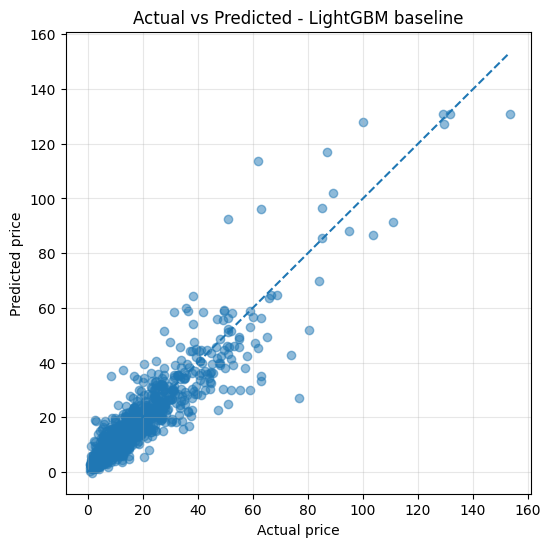

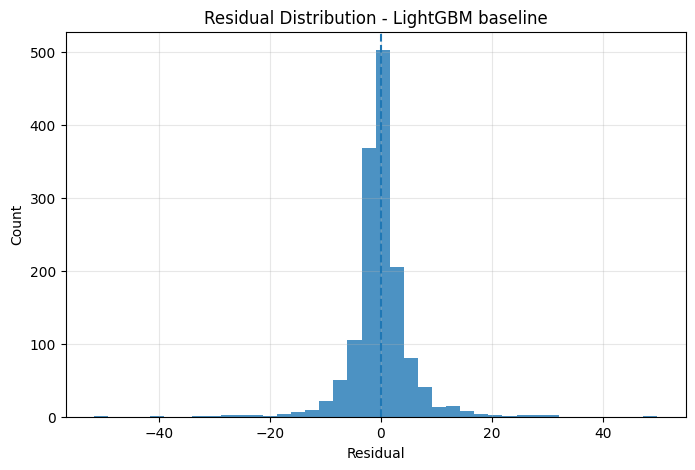

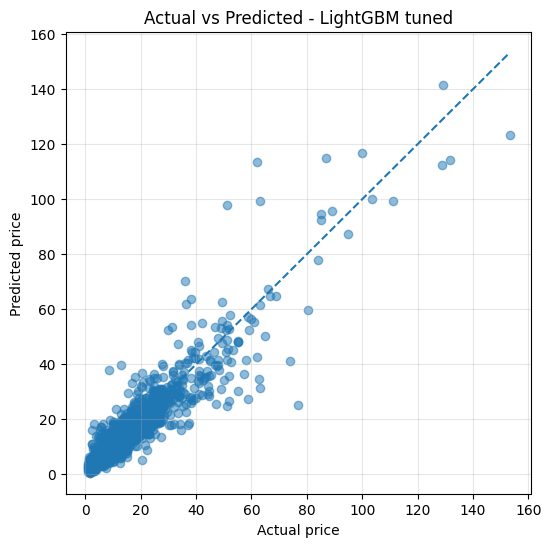

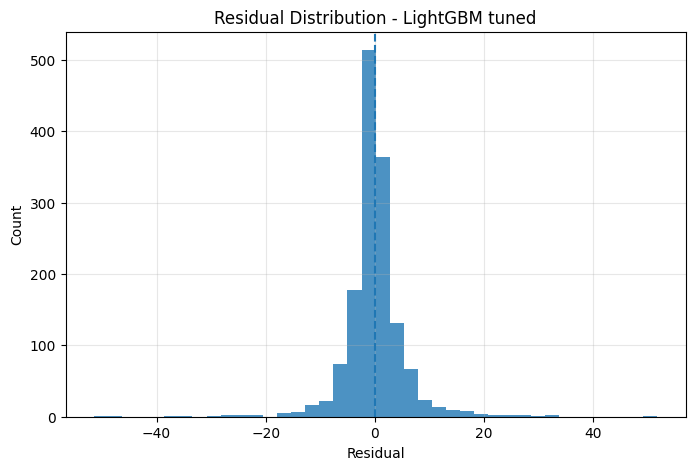

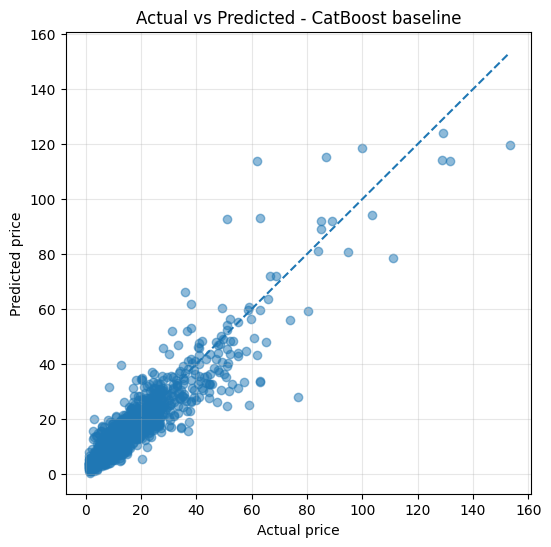

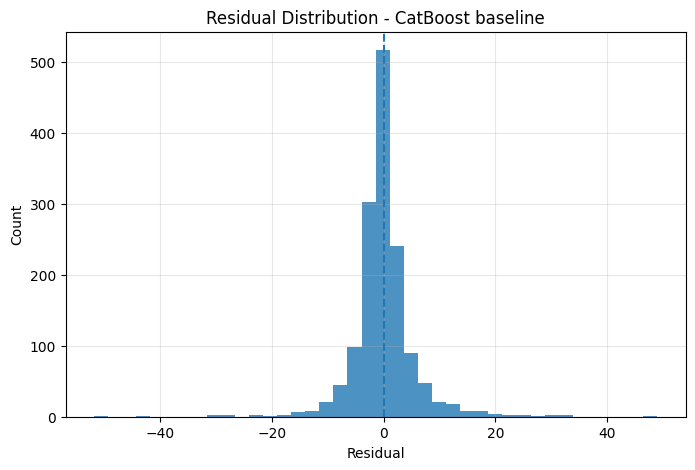

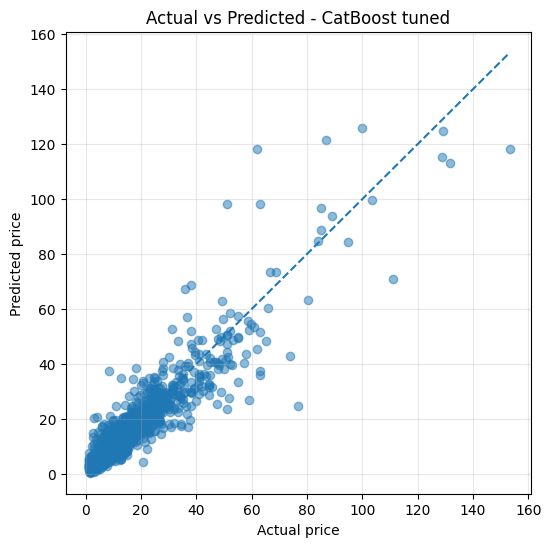

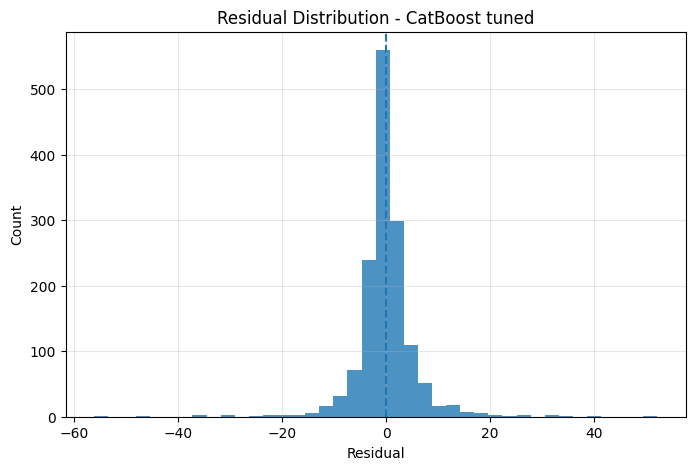

In [23]:
def plot_actual_vs_predicted(pred_df, model_name, version):
    plot_df = pred_df[
        (pred_df["model_name"] == model_name) &
        (pred_df["version"] == version)
    ].copy()

    plt.figure(figsize=(6, 6))
    plt.scatter(plot_df["actual_price"], plot_df["predicted_price"], alpha=0.5)

    min_val = min(plot_df["actual_price"].min(), plot_df["predicted_price"].min())
    max_val = max(plot_df["actual_price"].max(), plot_df["predicted_price"].max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    plt.title(f"Actual vs Predicted - {model_name} {version}")
    plt.xlabel("Actual price")
    plt.ylabel("Predicted price")
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_residual_distribution(pred_df, model_name, version):
    plot_df = pred_df[
        (pred_df["model_name"] == model_name) &
        (pred_df["version"] == version)
    ].copy()

    plt.figure(figsize=(8, 5))
    plt.hist(plot_df["residual"], bins=40, alpha=0.8)
    plt.axvline(0, linestyle="--")
    plt.title(f"Residual Distribution - {model_name} {version}")
    plt.xlabel("Residual")
    plt.ylabel("Count")
    plt.grid(True, alpha=0.3)
    plt.show()


for model_name in all_predictions_df["model_name"].unique():
    for version in ["baseline", "tuned"]:
        plot_actual_vs_predicted(all_predictions_df, model_name, version)
        plot_residual_distribution(all_predictions_df, model_name, version)

## Final Candidate Decision

The holdout candidate table is kept as a reference, but the final model selection is based on Stratified KFold mean RMSE and RMSE standard deviation.

In [24]:
# ============================================================
# Required object validation before final selection
# ============================================================

required_objects = [
    "comparison_df",
    "cv_summary_df",
    "cv_candidate_decision_df",
]

for obj_name in required_objects:
    if obj_name not in globals():
        raise ValueError(f"Missing required object: {obj_name}")

if comparison_df.empty:
    raise ValueError("comparison_df is empty.")

if cv_summary_df.empty:
    raise ValueError("cv_summary_df is empty. KFold stability evaluation may not have run.")

if cv_candidate_decision_df.empty:
    raise ValueError("cv_candidate_decision_df is empty. KFold candidate decision may not have run.")

# ============================================================
# Holdout candidate decision table (reference only)
# ============================================================

holdout_candidate_rows = []

for _, row in comparison_df.iterrows():
    model_name = row["model_name"]
    version = row["version"]

    model_decision = decision_df.loc[decision_df["model_name"] == model_name, "decision"]
    model_decision = model_decision.iloc[0] if not model_decision.empty else "unknown"

    if model_name == best_model_summary["best_model_name"] and version == best_model_summary["best_version"]:
        status = "primary_candidate_on_holdout"
        note = "Best model by holdout RMSE."
    elif version == "tuned" and model_decision == "keep_for_analysis":
        status = "secondary_candidate_on_holdout"
        note = "Shows a metric trade-off on holdout; keep for diagnostics or ensemble experiments."
    elif version == "tuned" and model_decision == "reject_tuned":
        status = "rejected_on_holdout"
        note = "Tuned version does not provide enough holdout evidence to replace its baseline."
    elif version == "tuned" and model_decision == "keep_tuned":
        status = "secondary_candidate_on_holdout"
        note = "Tuned version improves key holdout metrics but is not necessarily best by KFold."
    else:
        status = "baseline_reference_on_holdout"
        note = "Useful as a holdout comparison reference."

    holdout_candidate_rows.append({
        "model_name": model_name,
        "version": version,
        "rmse": row["rmse"],
        "mae": row["mae"],
        "r2": row["r2"],
        "mape_pct": row["mape_pct"],
        "candidate_status": status,
        "note": note,
    })

holdout_candidate_df = pd.DataFrame(holdout_candidate_rows)
holdout_candidate_df["status_order"] = holdout_candidate_df["candidate_status"].map({
    "primary_candidate_on_holdout": 0,
    "secondary_candidate_on_holdout": 1,
    "baseline_reference_on_holdout": 2,
    "rejected_on_holdout": 3,
}).fillna(9)
holdout_candidate_df = holdout_candidate_df.sort_values(["status_order", "rmse"]).drop(columns="status_order")

display(holdout_candidate_df)
holdout_candidate_df.to_csv(METRIC_DIR / "final_candidate_decision.csv", index=False)
print(f"Saved holdout candidate decision: {METRIC_DIR / 'final_candidate_decision.csv'}")

# ============================================================
# Final model selection from KFold
# ============================================================

final_selected = cv_candidate_decision_df.sort_values(
    ["mean_rmse", "std_rmse", "mean_mae"]
).iloc[0]

final_model_selection = {
    "selected_model_name": final_selected["model_name"],
    "selected_version": final_selected["version"],
    "selection_basis": "Stratified KFold mean RMSE",
    "mean_rmse": float(final_selected["mean_rmse"]),
    "std_rmse": float(final_selected["std_rmse"]),
    "mean_mae": float(final_selected["mean_mae"]),
    "std_mae": float(final_selected["std_mae"]),
    "mean_mape_pct": float(final_selected["mean_mape_pct"]),
    "std_mape_pct": float(final_selected["std_mape_pct"]),
    "candidate_status": final_selected["candidate_status"],
    "reason": final_selected["reason"],
}

# Validate required keys
required_final_keys = [
    "selected_model_name",
    "selected_version",
    "selection_basis",
    "mean_rmse",
    "std_rmse",
    "mean_mae",
    "std_mae",
]

for key in required_final_keys:
    if key not in final_model_selection:
        raise ValueError(f"Missing key in final_model_selection: {key}")

# ============================================================
# Save selected final candidate model
# ============================================================

selected_model_lookup = {
    ("LightGBM", "baseline"): lgbm_baseline,
    ("LightGBM", "tuned"): lgbm_tuned,
    ("CatBoost", "baseline"): cat_baseline,
    ("CatBoost", "tuned"): cat_tuned,
}

selected_key = (
    final_model_selection["selected_model_name"],
    final_model_selection["selected_version"],
)

if selected_key not in selected_model_lookup:
    raise ValueError(
        f"Selected model {selected_key} not found in selected_model_lookup. "
        f"Available keys: {list(selected_model_lookup.keys())}"
    )

selected_model = selected_model_lookup[selected_key]

selected_model_path = MODEL_DIR / "selected_final_candidate_model.pkl"

joblib.dump(
    selected_model,
    selected_model_path,
)

print(f"Saved selected final candidate model to: {selected_model_path}")

# Add path to metadata and re-save json
final_model_selection["selected_model_path"] = str(selected_model_path)
final_model_selection["cv_data_scope"] = "training_set_only"
final_model_selection["holdout_usage"] = "independent_sanity_check"

with open(PARAM_DIR / "final_model_selection.json", "w", encoding="utf-8") as f:
    json.dump(final_model_selection, f, indent=2, ensure_ascii=False)

display(pd.DataFrame([final_model_selection]))
print(f"Saved final model selection: {PARAM_DIR / 'final_model_selection.json'}")


,model_name,version,rmse,mae,r2,mape_pct,candidate_status,note
0,LightGBM,baseline,5.7849,3.3666,0.8559,31.9004,primary_candidate_on_holdout,Best model by holdout RMSE.
3,CatBoost,tuned,5.9127,3.3726,0.8495,32.2540,secondary_candidate_on_holdout,Shows a metric trade-off on holdout; keep for ...
1,CatBoost,baseline,5.8193,3.4741,0.8542,33.5088,baseline_reference_on_holdout,Useful as a holdout comparison reference.
2,LightGBM,tuned,5.8423,3.3703,0.8531,31.6658,rejected_on_holdout,Tuned version does not provide enough holdout ...


Saved holdout candidate decision: Y:\Python\Laptop-Price-Prediction\artifacts\hyperparameter_tuning\metrics\final_candidate_decision.csv
Saved selected final candidate model to: Y:\Python\Laptop-Price-Prediction\artifacts\hyperparameter_tuning\models\selected_final_candidate_model.pkl


,selected_model_name,selected_version,selection_basis,mean_rmse,std_rmse,mean_mae,std_mae,mean_mape_pct,std_mape_pct,candidate_status,reason,selected_model_path,cv_data_scope,holdout_usage
0,CatBoost,tuned,Stratified KFold mean RMSE,5.2256,0.2630,3.1840,0.1137,30.6727,0.9688,primary_candidate,Best mean RMSE across Stratified KFold and sta...,Y:\Python\Laptop-Price-Prediction\artifacts\hy...,training_set_only,independent_sanity_check


Saved final model selection: Y:\Python\Laptop-Price-Prediction\artifacts\hyperparameter_tuning\params\final_model_selection.json


## Final Conclusion

This notebook performs hyperparameter tuning and model selection without using the holdout set during the selection process.

Hyperparameter tuning is done on the training split using stratified cross-validation. After tuning, all baseline and tuned candidates are evaluated again with Stratified KFold on the training set only. This gives a more stable estimate of model performance while keeping the holdout set independent.

The holdout result is used only as a sanity check. It should not be used to select the final candidate directly.

The selected model and its metadata are saved as:

- `selected_final_candidate_model.pkl`
- `final_model_selection.json`

The next notebook should load these artifacts and perform final evaluation, diagnostics, segment-level error analysis, large-error inspection, and SHAP or feature importance analysis.

In [25]:
from IPython.display import Markdown, display

selected_name = final_model_selection["selected_model_name"]
selected_version = final_model_selection["selected_version"]

selected_row = cv_summary_df[
    (cv_summary_df["model_name"] == selected_name)
    & (cv_summary_df["version"] == selected_version)
].iloc[0]

same_model_rows = cv_summary_df[cv_summary_df["model_name"] == selected_name].set_index("version")

conclusion_lines = [
    "### Data-driven final decision",
    "",
    f"- Final selected candidate: **{selected_name} ({selected_version})**.",
    f"- Selection basis: {final_model_selection['selection_basis']}.",
    f"- KFold mean RMSE={final_model_selection['mean_rmse']:,.4f}, std RMSE={final_model_selection['std_rmse']:,.4f}, mean MAE={final_model_selection['mean_mae']:,.4f}.",
]

if {"baseline", "tuned"}.issubset(set(same_model_rows.index)):
    baseline_rmse = same_model_rows.loc["baseline", "mean_rmse"]
    tuned_rmse = same_model_rows.loc["tuned", "mean_rmse"]
    if selected_version == "tuned" and tuned_rmse < baseline_rmse:
        conclusion_lines.append(
            f"- The tuned {selected_name} replaces its baseline because it improves KFold mean RMSE."
        )
    elif selected_version == "baseline" and tuned_rmse >= baseline_rmse:
        conclusion_lines.append(
            f"- The {selected_name} baseline remains preferred because the tuned version does not improve KFold mean RMSE."
        )

holdout_best = comparison_df.sort_values(["rmse", "mae", "mape_pct"]).iloc[0]
if holdout_best["model_name"] == selected_name and holdout_best["version"] == selected_version:
    conclusion_lines.append("- Holdout and KFold agree on the leading candidate.")
else:
    conclusion_lines.append(
        f"- Holdout best was {holdout_best['model_name']} ({holdout_best['version']}), but KFold selection takes priority because it evaluates multiple splits."
    )

conclusion_lines.append(
    "- The notebook now answers: best tuning params, baseline-vs-tuned stability across KFold, and final candidate selection from KFold mean/std RMSE."
)
conclusion_lines.append(
    "- Notebook 14 should use `final_model_selection.json` for final evaluation, diagnostics, error analysis, SHAP/feature importance, and export."
)

display(Markdown("\n".join(conclusion_lines)))

### Data-driven final decision

- Final selected candidate: **CatBoost (tuned)**.
- Selection basis: Stratified KFold mean RMSE.
- KFold mean RMSE=5.2256, std RMSE=0.2630, mean MAE=3.1840.
- The tuned CatBoost replaces its baseline because it improves KFold mean RMSE.
- Holdout best was LightGBM (baseline), but KFold selection takes priority because it evaluates multiple splits.
- The notebook now answers: best tuning params, baseline-vs-tuned stability across KFold, and final candidate selection from KFold mean/std RMSE.
- Notebook 14 should use `final_model_selection.json` for final evaluation, diagnostics, error analysis, SHAP/feature importance, and export.

## Output Artifact Check

This section verifies that all required artifacts for the next notebook were created successfully. The next notebook should load `final_model_selection.json` and `selected_final_candidate_model.pkl`.

In [26]:
expected_output_files = [
    METRIC_DIR / "final_tuned_comparison.csv",
    METRIC_DIR / "tuning_decision_table.csv",
    METRIC_DIR / "train_kfold_fold_metrics.csv",
    METRIC_DIR / "train_kfold_cv_summary.csv",
    METRIC_DIR / "train_kfold_candidate_decision.csv",
    METRIC_DIR / "kfold_fold_metrics.csv",
    METRIC_DIR / "kfold_cv_summary.csv",
    METRIC_DIR / "kfold_candidate_decision.csv",
    METRIC_DIR / "holdout_vs_kfold_comparison.csv",
    PARAM_DIR / "best_params_lightgbm.json",
    PARAM_DIR / "best_params_catboost.json",
    PARAM_DIR / "final_model_selection.json",
    MODEL_DIR / "lightgbm_target_price_baseline.pkl",
    MODEL_DIR / "catboost_target_price_baseline.pkl",
    MODEL_DIR / "lightgbm_target_price_tuned.pkl",
    MODEL_DIR / "catboost_target_price_tuned.pkl",
    MODEL_DIR / "selected_final_candidate_model.pkl",
    PRED_DIR / "tuned_test_predictions.csv",
    PRED_DIR / "train_kfold_oof_predictions.csv",
    PRED_DIR / "kfold_oof_predictions.csv",
]

output_check_rows = []

for path in expected_output_files:
    output_check_rows.append({
        "path": str(path),
        "exists": path.exists(),
        "size_bytes": path.stat().st_size if path.exists() else 0,
    })

output_check_df = pd.DataFrame(output_check_rows)
display(output_check_df)

missing_outputs = output_check_df[~output_check_df["exists"]]

if not missing_outputs.empty:
    raise FileNotFoundError(
        "Some expected output files are missing:\n"
        + "\n".join(missing_outputs["path"].tolist())
    )

print("All expected output artifacts are present.")


,path,exists,size_bytes
0,Y:\Python\Laptop-Price-Prediction\artifacts\hy...,True,859
1,Y:\Python\Laptop-Price-Prediction\artifacts\hy...,True,1136
2,Y:\Python\Laptop-Price-Prediction\artifacts\hy...,True,2888
3,Y:\Python\Laptop-Price-Prediction\artifacts\hy...,True,1145
4,Y:\Python\Laptop-Price-Prediction\artifacts\hy...,True,1029
5,Y:\Python\Laptop-Price-Prediction\artifacts\hy...,True,2888
6,Y:\Python\Laptop-Price-Prediction\artifacts\hy...,True,1145
7,Y:\Python\Laptop-Price-Prediction\artifacts\hy...,True,1029
8,Y:\Python\Laptop-Price-Prediction\artifacts\hy...,True,1133
9,Y:\Python\Laptop-Price-Prediction\artifacts\hy...,True,211


All expected output artifacts are present.
